In [ ]:
pip install tensorflow pandas numpy scikit-learn matplotlib seaborn

          Time  Date Day of the week  CarCount  BikeCount  BusCount  \
0  12:00:00 AM    10         Tuesday        31          0         4   
1  12:15:00 AM    10         Tuesday        49          0         3   
2  12:30:00 AM    10         Tuesday        46          0         3   
3  12:45:00 AM    10         Tuesday        51          0         2   
4   1:00:00 AM    10         Tuesday        57          6        15   

   TruckCount  Total Traffic Situation  
0           4     39               low  
1           3     55               low  
2           6     55               low  
3           5     58               low  
4          16     94            normal  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2976 entries, 0 to 2975
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Time               2976 non-null   object
 1   Date               2976 non-null   int64 
 2   Day of the week    2976 non-

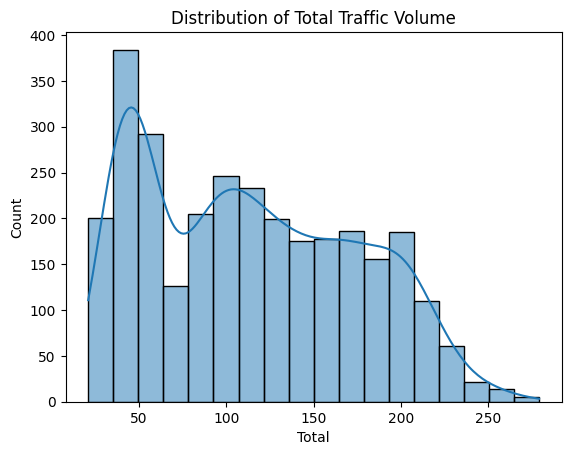

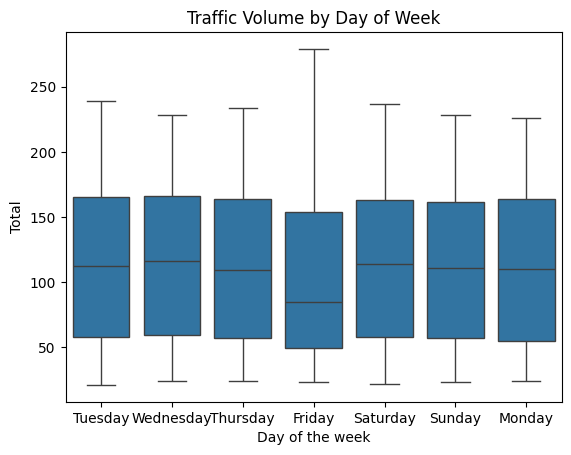

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Traffic.csv')
print(df.head())
print(df.info())
print(df.describe())

# Basic visualizations
sns.histplot(df['Total'], kde=True)
plt.title('Distribution of Total Traffic Volume')
plt.show()

sns.boxplot(x='Day of the week', y='Total', data=df)
plt.title('Traffic Volume by Day of Week')
plt.show()

In [ ]:
# Extract useful time features
df['Hour'] = pd.to_datetime(df['Time'], format='%I:%M:%S %p').dt.hour
df['Is_Weekend'] = df['Day of the week'].isin(['Saturday', 'Sunday']).astype(int)

# One-hot encode categorical features
df = pd.get_dummies(df, columns=['Day of the week'], drop_first=True)

# Select features and target
features = ['Hour', 'Is_Weekend', 'CarCount', 'BikeCount', 'BusCount', 'TruckCount'] + \
           [col for col in df.columns if col.startswith('Day of the week_')]
X = df[features]
y = df['Total']   # ← Regression target

# Train-test split + scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='linear')   # Regression → linear output
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,457 (13.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 15414.4980 - mae: 108.5900 - val_loss: 12205.8896 - val_mae: 93.1480
Epoch 2/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5231.1064 - mae: 55.1494 - val_loss: 600.9254 - val_mae: 19.8717
Epoch 3/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 790.6509 - mae: 22.4559 - val_loss: 361.7406 - val_mae: 15.7267
Epoch 4/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 624.1071 - mae: 19.5174 - val_loss: 262.6149 - val_mae: 13.0772
Epoch 5/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 550.7171 - mae: 18.4119 - val_loss: 202.5133 - val_mae: 11.4796
Epoch 6/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 503.8409 - mae: 17.5898 - val_loss: 144.3188 - val_mae: 9.6310
Epoch 7/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 479.9458 - mae: 16.9441 - val_loss: 117.6612 - val_mae: 8.7768
Epoch 8/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 409.8557 - mae: 15.5138 - val_loss: 103.3162 - val_mae: 8.1247
Epoch 9/100


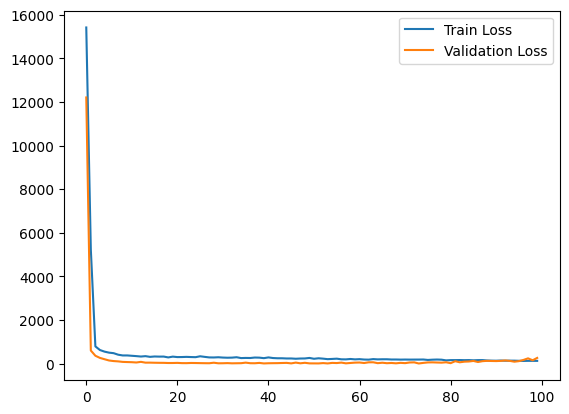

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# Plot training curves
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test).flatten()

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
MAE: 13.51
RMSE: 16.15
R² Score: 0.9226


In [ ]:
# Example: Try different architectures
def build_model(layers_neurons=[64,32,16], dropout=0.2):
    model = keras.Sequential()
    model.add(layers.Dense(layers_neurons[0], activation='relu', input_shape=(X_train.shape[1],)))
    model.add(layers.Dropout(dropout))
    for n in layers_neurons[1:]:
        model.add(layers.Dense(n, activation='relu'))
        model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1, activation='linear'))
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Test 2-3 combinations and record best MAE/RMSE

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

# Build a new model with a different architecture
model_2 = build_model(layers_neurons=[128, 64, 32], dropout=0.3)
model_2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,033 (47.00 KB)

 Trainable params: 12,033 (47.00 KB)

 Non-trainable params: 0 (0.00 B)

Training model_2...


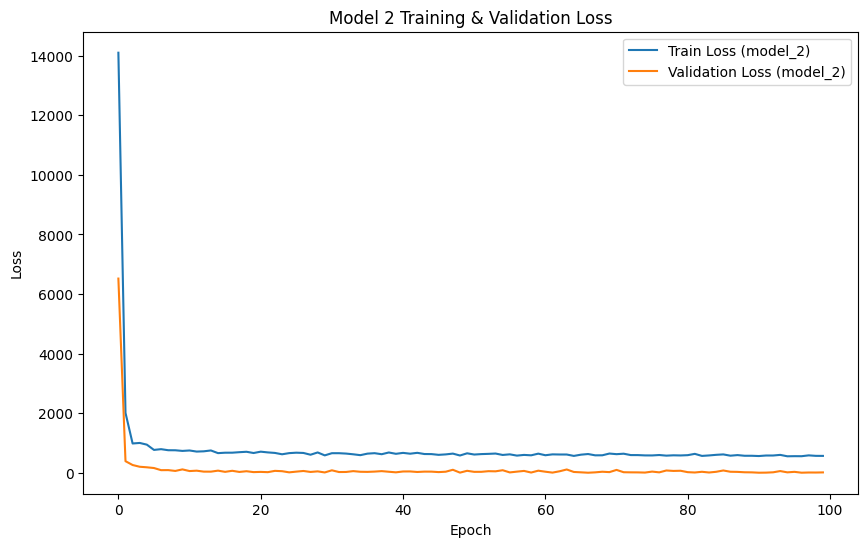

In [ ]:
print("Training model_2...")
history_2 = model_2.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=0 # Set verbose to 0 to suppress output for brevity during automated run
)

# Plot training curves for model_2
plt.figure(figsize=(10, 6))
plt.plot(history_2.history['loss'], label='Train Loss (model_2)')
plt.plot(history_2.history['val_loss'], label='Validation Loss (model_2)')
plt.title('Model 2 Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
print("Evaluating model_2...")
y_pred_2 = model_2.predict(X_test).flatten()

mae_2 = mean_absolute_error(y_test, y_pred_2)
rmse_2 = np.sqrt(mean_squared_error(y_test, y_pred_2))
r2_2 = r2_score(y_test, y_pred_2)

print(f"Model 2 MAE: {mae_2:.2f}")
print(f"Model 2 RMSE: {rmse_2:.2f}")
print(f"Model 2 R² Score: {r2_2:.4f}")

Evaluating model_2...
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Model 2 MAE: 3.32
Model 2 RMSE: 4.07
Model 2 R² Score: 0.9951
